In [72]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
from kneed import KneeLocator
from sklearn.decomposition import PCA

# RQ 3: Cluster Analysis & Profiling (Unsupervised Success Profiles)

In [73]:
# Load the dataset
df_spotify = pd.read_csv('../data/spotify_mid.csv')

## Data filter and scaling
Here we create a data subset containing only tracks where *is_hit = 1* (successful songs) 

In [74]:
# Subset for successful songs
hit_df = df_spotify[df_spotify['popularity'] >= 70].copy()

# Define the audio features for clustering
# Excluding key, mode, and time_signature for simplicity, focusing on normalized features
feature_cols = [
    'danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_s'
]

successful_songs = hit_df[feature_cols]
successful_songs

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_s
0,0.676,0.4610,-6.746,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,230
3,0.266,0.0596,-18.515,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,201
4,0.618,0.4430,-9.681,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,198
6,0.407,0.1470,-8.822,0.0355,0.8570,0.000003,0.0913,0.0765,141.284,229
7,0.703,0.4440,-9.331,0.0417,0.5590,0.000000,0.0973,0.7120,150.960,242
...,...,...,...,...,...,...,...,...,...,...
112007,0.771,0.8260,-3.978,0.0604,0.1420,0.030000,0.1450,0.1850,100.012,212
112249,0.442,0.7300,-4.673,0.0755,0.0781,0.000005,0.1560,0.3810,97.062,193
112399,0.575,0.3660,-13.644,0.0281,0.5680,0.957000,0.1290,0.4440,100.004,223
112649,0.552,0.6080,-11.211,0.0274,0.1480,0.000021,0.3320,0.8350,88.002,188


In [75]:
# Standardize the features
scaler = StandardScaler()
successful_scaled = scaler.fit_transform(successful_songs)

print(f"Number of 'hit' tracks: {hit_df.shape[0]}")
print(f"Scaled feature matrix shape: {successful_scaled.shape}")

Number of 'hit' tracks: 5472
Scaled feature matrix shape: (5472, 10)


## Optimal K determination (Elbow Method)

Use the elbow method to find the optimal number of clusters by calculating inertia.

### Calculate Inertia for Different K Values
Since the Elbow Point changes on different executions of K-Means, we'll do it for N times (e.g N=400) and than select the elbow point that appears more times.

In [125]:
# Elbow method to find the optimal number of clusters.
inertia_list = []
K = range(1, 10)
N = 400

for _ in range(N):
    inertia = []
    for k in K:
        kmeans = KMeans(n_clusters=k)
        kmeans.fit(successful_scaled)
        inertia.append(kmeans.inertia_)
    inertia_list.append(inertia)

### Visualize Elbow Plot

Plot the elbow graph to identify the optimal number of clusters.

In [126]:
inertia_mean = np.mean(inertia_list, axis=0)
inertia_std = np.std(inertia_list, axis=0)

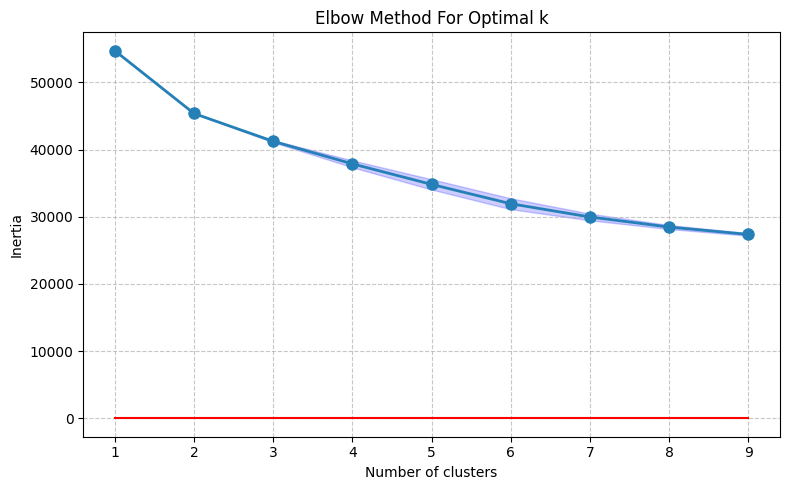

In [127]:
# Plot the elbow graph.
plt.figure(figsize=(8, 5))
plt.plot(K, inertia_mean, "o-", markersize=8, linewidth=2, color="#2580B7")
plt.fill_between(K, inertia_mean - inertia_std, inertia_mean + inertia_std, color='blue', alpha=0.2, label='Std Dev')
plt.plot(K, np.zeros(K.stop-1), color="red")

# Add labels to the plot.
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method For Optimal k")
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

As we can see from this plot, it's clear that between different trials we have some deviation around 4-7, \
which is the reason why it was not enough to select the elbow point from only one trial.

### Find Optimal K with KneeLocator

Use the KneeLocator library to automatically detect the elbow point.

In [129]:
# Use the KneeLocator from the kneed library to find the elbow point.
elbows = []
for i in range(N):
    kl = KneeLocator(K, inertia_list[i], curve="convex", direction="decreasing")
    elbows.append(kl.elbow)
    
[{i: elbows.count(int(i))} for i in K]

[{1: 0}, {2: 0}, {3: 36}, {4: 83}, {5: 109}, {6: 120}, {7: 52}, {8: 0}, {9: 0}]

From this output, 6 is considered the elbow point which appears the most of times along different trials

### Apply K-Means with Optimal K

Apply k-means clustering with the optimal number of clusters and visualize the results.

In [130]:
elbow_point = 6

In [131]:
# Apply the k-means algorithm.
kmeans = KMeans(n_clusters=elbow_point, random_state=42, n_init=10)
hit_df['cluster'] = kmeans.fit_predict(successful_scaled)

For visualization purposes, we apply PCA \
*It's not necessary to center data since we're already scaled it before*

In [132]:
# Apply PCA from sklearn.decomposition
pca = PCA(n_components=2)
successfull_pca = pca.fit_transform(successful_scaled)

# Project the 10D centroids into the same 2D space
centroids_2d = pca.transform(kmeans.cluster_centers_)

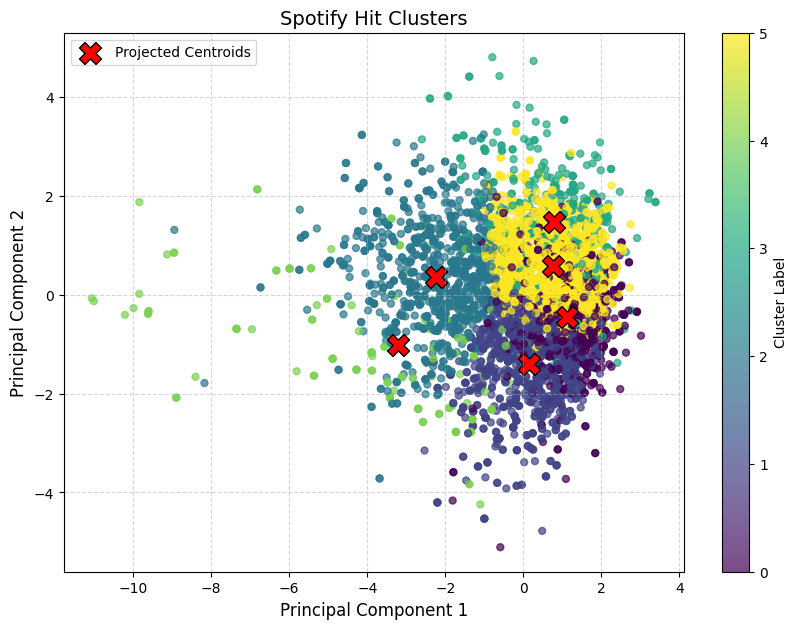

In [133]:
# Visualize the clusters
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    successfull_pca[:, 0], successfull_pca[:, 1], 
    c=hit_df['cluster'], 
    cmap='viridis', 
    s=25, alpha=0.7
)

# Plot the projected centroids
plt.scatter(
    centroids_2d[:, 0], centroids_2d[:, 1], 
    s=250, marker="X", c='red', edgecolor='black', label="Projected Centroids"
)

plt.title("Spotify Hit Clusters", fontsize=14)
plt.xlabel("Principal Component 1", fontsize=12)
plt.ylabel("Principal Component 2", fontsize=12)
plt.colorbar(scatter, ticks=range(elbow_point), label='Cluster Label')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

In [134]:
# Profile the clusters (interpret the 10D results)
cluster_profiles = hit_df.groupby('cluster')[feature_cols + ['popularity']].mean().round(3)
cluster_profiles

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_s,popularity
cluster,,,,,,,,,,,
0,0.610,0.791,-5.236,0.071,0.101,0.015,0.404,0.572,121.615,206.667,75.704
1,0.488,0.752,-5.862,0.057,0.080,0.021,0.138,0.374,134.433,252.689,75.619
2,0.554,0.412,-10.003,0.046,0.577,0.018,0.144,0.349,112.595,225.721,75.048
3,0.721,0.671,-6.234,0.285,0.235,0.008,0.155,0.566,125.564,200.900,76.867
4,0.494,0.520,-11.798,0.049,0.384,0.751,0.141,0.321,119.938,217.450,74.468
5,0.714,0.724,-5.604,0.060,0.150,0.008,0.124,0.638,113.912,201.628,76.478


In [ ]:
# For each cluster, find the 4 genres with the highest count
for i in range(elbow_point):
    top_genres = hit_df[hit_df['cluster'] == i]['track_genre'].value_counts().head(4)
    print(f"Cluster {i} Top Genres: {top_genres.index.tolist()}")

Cluster 0 Top Genres: ['house', 'k-pop', 'edm', 'metal']
Cluster 1 Top Genres: ['metal', 'hard-rock', 'alt-rock', 'rock']
Cluster 2 Top Genres: ['pop', 'singer-songwriter', 'songwriter', 'indie']
Cluster 3 Top Genres: ['latino', 'hip-hop', 'reggaeton', 'reggae']
Cluster 4 Top Genres: ['indie', 'indie-pop', 'ambient', 'alt-rock']
Cluster 5 Top Genres: ['dance', 'house', 'pop', 'k-pop']


### Clusters from K-Means Interpretation
Based on the refined cluster analysis (Optimal K=6), we have identified six distinct "Success Profiles" for Spotify tracks. 

These represent unique combinations of audio characteristics that define successful hits in the dataset.

---

#### **Cluster 0**
* **Signature:** High **Energy** (0.791) and the highest **Liveness** (0.404) in the dataset.
* **Vibe:** Tracks that feel "big" and performative, likely capturing the essence of a live concert or stadium event. They are upbeat and driving.
* **Commercial Strategy:** Success is driven by "presence" and intensity. These are the songs that get crowds moving at festivals or live shows.

#### **Cluster 1**
* **Signature:** Highest **Tempo** (134.4 BPM) and longest **Duration** (252.7s).
* **Vibe:** Fast-paced, high-energy tracks with longer arrangements. This is the classic profile for **Rock, Metal, or Progressive Electronic** music.
* **Commercial Strategy:** Appeals to dedicated listeners who enjoy immersive, longer song structures. Their success is built on "momentum" and technical energy.

#### **Cluster 2**
* **Signature:** Highest **Acousticness** (0.577) and lowest **Energy** (0.412).
* **Vibe:** Stripped-back, intimate, and organic. Primarily driven by vocals and acoustic instruments (guitar/piano).
* **Commercial Strategy:** These are "emotional hits." They succeed through lyrical storytelling and vulnerability, making them staples for singer-songwriter and moody/chill playlists.

#### **Cluster 3**
* **Signature:** Highest **Speechiness** (0.285) and highest **Danceability** (0.721).
* **Vibe:** Rhythm-focused tracks with a heavy emphasis on lyrics and vocal delivery. This is the archetype for **Hip-Hop, Rap, and Reggaeton**.
* **Commercial Strategy:** This is the most popular cluster (**Popularity: 76.87**). It dominates the modern charts through rhythmic "catchiness" and cultural relatability.

#### **Cluster 4**
* **Signature:** Highest **Instrumentalness** (0.751) and lowest **Loudness** (-11.8 dB).
* **Vibe:** Mostly wordless, quiet, and atmospheric. These tracks focus on texture and mood rather than melody or energy.
* **Commercial Strategy:** These are "Background Hits." They find massive success in "Utility Playlists"—music for focus, studying, sleep, or relaxation.

#### **Cluster 5**
* **Signature:** Highest **Valence** (0.638) and high **Danceability** (0.714).
* **Vibe:** Happy, upbeat, and extremely catchy. These are designed specifically for the dance floor and positive social settings.
* **Commercial Strategy:** Pure commercial pop appeal. These tracks are engineered for high-rotation radio and "Today's Top Hits" style playlists.

---